# Portfolio Snapshot Report

A simple, investor-facing view: current positions, portfolio value over time, and
performance vs. benchmark. Deliberately minimal — one chart, one table — reading
directly from `data/portfolio_snapshot_<name>.csv` (written automatically by
`daily_runner.py` every run, independent of rebalance schedule).

This is NOT a replacement for the trade log or `measure_live_performance()` — it's a
faster, higher-level view for "how are we doing" without needing to replay every trade.

In [1]:
# Package is pip-installed editable, no sys.path hacking needed
import os
from dotenv import load_dotenv
from momentum_trading.execution.live_signal import (
    get_latest_snapshot, measure_live_performance, fetch_live_prices,
    fetch_ohlcv_for_tickers, build_position_performance, TRADE_LOG_PATH,
)
from momentum_trading.core.paths import data_dir
from momentum_trading.core.technical_indicators import compute_latest_indicators
from momentum_trading.core.fundamentals import get_cached_or_fetch_fundamentals
from momentum_trading.core.macro_data import get_cached_or_fetch_macro_indicators
from momentum_trading.interfaces.notifications import build_comparison_bar_chart
import momentum_trading.core.functions_quant_extensions as fnx
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image

# Loads FMP_API_KEY/EODHD_API_KEY/FRED_API_KEY from ../../.env into this process — unlike the
# CLI (run with the shell/Docker env already populated), the notebook kernel won't see .env
# unless we load it explicitly.
load_dotenv("../../.env")

True

## 1. Current snapshot

In [2]:
# EDIT: your portfolio name from config.yaml
portfolio_name = "portfolio1"

latest = get_latest_snapshot(portfolio_name)
if latest is None:
    print(f"No snapshot log found yet for '{portfolio_name}'. Run daily_runner.py at least once first.")
else:
    print(f"As of: {latest['date']}")
    print(f"Total value:     ${float(latest['total_value']):,.2f}")
    print(f"Cash:            ${float(latest['cash']):,.2f}")
    print(f"Positions value: ${float(latest['positions_value']):,.2f}")
    print(f"Unrealized P&L:  ${float(latest['unrealized_pnl']):,.2f}")
    print(f"Open positions:  {latest['n_positions']}")
    if latest['positions_detail']:
        print("\nPositions:")
        for p in str(latest['positions_detail']).split(';'):
            print(f"  {p}")

As of: 2026-07-17
Total value:     $500.00
Cash:            $500.00
Positions value: $0.00
Unrealized P&L:  $0.00
Open positions:  0

Positions:
  nan


## 2. Cumulative return vs. benchmark

In [3]:
comparison = fnx.compare_to_benchmark(portfolio_name)
if "error" in comparison:
    print(comparison["error"])
elif comparison["n_periods"] == 0:
    print("Not enough snapshots yet to compute a period return (need at least 2 runs).")
else:
    print(f"As of: {comparison['as_of_date'].date()}  ({comparison['n_periods']} periods)")
    print(f"Portfolio cumulative return: {comparison['portfolio_cumulative_return']:.2%}")
    print(f"Benchmark cumulative return: {comparison['benchmark_cumulative_return']:.2%}")
    print(f"Outperformance:              {comparison['outperformance']:+.2%}")

As of: 2026-07-11  (5 periods)
Portfolio cumulative return: 0.00%
Benchmark cumulative return: 0.00%
Outperformance:              +0.00%


## 3. Portfolio value over time

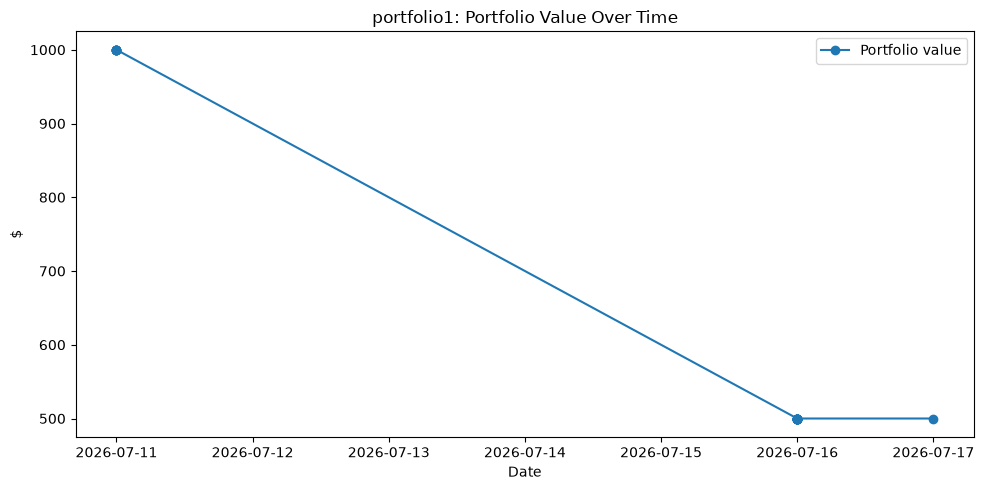

,date,total_value,cash,positions_value,unrealized_pnl,n_positions
15,2026-07-16,500.0,0.0,797.62,-6.78,4
16,2026-07-16,500.0,0.0,797.62,-6.78,4
17,2026-07-16,500.0,0.0,797.62,-6.79,4
18,2026-07-16,500.0,0.0,797.62,-6.79,4
19,2026-07-16,500.0,0.0,797.62,-6.79,4
20,2026-07-16,500.0,0.0,797.62,-6.79,4
21,2026-07-16,500.0,0.0,571.62,-4.71,4
22,2026-07-16,500.0,0.0,571.62,-4.71,4
23,2026-07-16,500.0,0.0,571.62,-4.71,4
24,2026-07-17,500.0,500.0,0.00,0.00,0


In [4]:
snapshot_path = str(data_dir() / f"portfolio_snapshot_{portfolio_name}.csv")
try:
    df = pd.read_csv(snapshot_path, parse_dates=["date"])
    plt.figure(figsize=(10, 5))
    plt.plot(df["date"], df["total_value"], marker="o", label="Portfolio value")
    plt.title(f"{portfolio_name}: Portfolio Value Over Time")
    plt.ylabel("$")
    plt.xlabel("Date")
    plt.legend()
    plt.tight_layout()
    plt.show()
    display(df[["date", "total_value", "cash", "positions_value", "unrealized_pnl", "n_positions"]].tail(10))
except FileNotFoundError:
    print(f"No snapshot file at {snapshot_path} yet.")

---
## 4. Correlation with your OTHER holdings

This strategy's internal correlation penalty only looks at correlation AMONG its own
picks — it has no visibility into anything else you own. A momentum sleeve that looks
well-diversified internally can still be highly correlated with the rest of your net worth.

Fill in your other holdings' periodic returns below (e.g. from your brokerage statements
or another return series) to check this before committing significant capital.

In [5]:
# EDIT: replace with your actual strategy period returns (from the snapshot log,
# once you have >=2 snapshots) and your other holdings' returns, same frequency/index.
snapshot_path = str(data_dir() / f"portfolio_snapshot_{portfolio_name}.csv")
try:
    snap_df = pd.read_csv(snapshot_path, parse_dates=["date"]).dropna(subset=["portfolio_period_return"])
    strategy_returns = snap_df.set_index("date")["portfolio_period_return"]

    if len(strategy_returns) < 3:
        print("Not enough periods yet for a meaningful correlation check (need several snapshots).")
    else:
        # EDIT: supply your other real holdings' returns here, aligned by date
        other_holdings_returns = {
            # "my_sp500_index_fund": pd.Series({...}),
            # "my_bond_fund": pd.Series({...}),
        }
        if not other_holdings_returns:
            print("No other holdings supplied yet — edit the cell above to add your real return series.")
        else:
            result = fnx.check_external_correlation(strategy_returns, other_holdings_returns)
            for name, stats in result["per_holding"].items():
                print(f"{name}: correlation={stats['correlation']:.2f} ({stats['n_overlapping_periods']} overlapping periods)")
            for w in result["warnings"]:
                print(f"\n⚠️  {w}")
except FileNotFoundError:
    print(f"No snapshot file at {snapshot_path} yet.")

No other holdings supplied yet — edit the cell above to add your real return series.


---
## 5. Position Performance (since entry)

Per-ticker return since entry — the same measure the live email reports show in their
"Position Performance (since entry)" section (`execution/live_signal.py`'s
`build_position_performance()`). That function needs a `current_positions` dict with
`shares`/`avg_entry_price` per ticker, which in production comes from a live IBKR connection
(`get_ibkr_positions()`) — not something these dry-run-only walkthrough notebooks do. Two ways
to see it here instead:

**5a** reconstructs real entry price/shares from your actual trade log via FIFO lot matching
(`measure_live_performance()`'s `open_position_avg_cost`), marked to a real live current price.

**5b** is a hand-built illustrative example (for when you don't have a trade log yet), also
marked to a real live current price, so the numbers aren't entirely synthetic.

In [6]:
# 5a. Real data — reconstructed from your trade log
today = pd.Timestamp.today().strftime("%Y-%m-%d")
try:
    perf = measure_live_performance("1970-01-01", today, log_path=TRADE_LOG_PATH)
    current_positions = {
        t: {"shares": perf["open_positions"][t], "avg_entry_price": perf["open_position_avg_cost"][t]}
        for t in perf["open_positions"]
    }
except FileNotFoundError:
    current_positions = {}
    print(f"No trade log yet at {TRADE_LOG_PATH} — run daily_runner.py (or --force-rebalance) at least once first.")

real_position_performance = {}
if current_positions:
    live_prices_df = fetch_live_prices(list(current_positions.keys()))
    latest_prices = live_prices_df.iloc[-1].to_dict()
    real_position_performance = build_position_performance(current_positions, latest_prices, TRADE_LOG_PATH)
    display(pd.DataFrame(real_position_performance).T)
else:
    print("No open positions found in the trade log.")

No trade log yet at C:\Users\Denys\Downloads\test3\momentum-trading\logs\live_trades_log.csv — run daily_runner.py (or --force-rebalance) at least once first.
No open positions found in the trade log.


### 5b. Illustrative example (entry data hand-picked, current price live)

Useful if you don't have a real trade log yet — shows the SAME `build_position_performance()`
function, but with a hand-picked entry price/shares for one or two well-known tickers (same
style `daily_runner_walkthrough.ipynb` uses for its stop-loss demo) combined with a REAL live
current-price fetch, so it's not entirely synthetic.

In [7]:
# EDIT: replace with tickers/entry prices/shares you want to illustrate
mock_positions = {
    "SPY": {"shares": 10.0, "avg_entry_price": 550.0},
    "QQQ": {"shares": 5.0, "avg_entry_price": 480.0},
}
mock_entry_dates = {"SPY": "2026-05-15", "QQQ": "2026-05-15"}  # illustrative only — not from a real log

mock_prices_df = fetch_live_prices(list(mock_positions.keys()))
mock_latest_prices = mock_prices_df.iloc[-1].to_dict()

illustrative_position_performance = build_position_performance(mock_positions, mock_latest_prices, TRADE_LOG_PATH)
# The trade log has no history for these mock tickers, so entry_date comes back None --
# overlay the illustrative entry dates above so the example reads naturally.
for t, illustrative_date in mock_entry_dates.items():
    if t in illustrative_position_performance:
        illustrative_position_performance[t]["entry_date"] = pd.Timestamp(illustrative_date)

display(pd.DataFrame(illustrative_position_performance).T)

# Sections 6-8 below need SOME ticker list — prefer your real open positions, fall back
# to the illustrative tickers so those sections always show something.
held_tickers = list(real_position_performance.keys()) or list(mock_positions.keys())
print(f"\nUsing tickers for sections 6-8 below: {held_tickers}")

2026-07-18 10:46:45,178 | INFO | Fetching live prices for 2 tickers, 2025-06-13 to 2026-07-18


Determining best data source using SPY...
Data retrieved from yf for SPY
Using yf for all tickers
Data retrieved from yf for SPY
Data retrieved from yf for QQQ


,entry_date,entry_price,current_price,shares,return_pct,market_value
SPY,2026-05-15 00:00:00,550.0,743.289978,10.0,0.351436,7432.89978
QQQ,2026-05-15 00:00:00,480.0,695.330017,5.0,0.448604,3476.650085



Using tickers for sections 6-8 below: ['SPY', 'QQQ']


---
## 6. Technical Indicators (held positions)

SMA/EMA (trend), ADX (trend strength), RSI/MACD (momentum), ATR/Bollinger Bands/rolling Std Dev
(volatility), VWAP/OBV (volume) — computed on ~60 days of OHLCV via `core/technical_indicators.py`'s
`compute_latest_indicators()`, fetched with `execution/live_signal.py`'s `fetch_ohlcv_for_tickers()`.
Same function the email reports use for their "Technical Indicators (held positions)" section.

In [8]:
ohlcv = fetch_ohlcv_for_tickers(held_tickers)
technical_indicators = {t: compute_latest_indicators(df) for t, df in ohlcv.items()}
technical_with_data = {t: v for t, v in technical_indicators.items() if v}
if technical_with_data:
    display(pd.DataFrame(technical_with_data).T)
else:
    print("No technical indicators computed — not enough OHLCV history yet for these tickers.")

Data retrieved from Yahoo Finance for SPY
Data retrieved from Yahoo Finance for QQQ


,sma_20,ema_20,adx_14,rsi_14,macd,macd_signal,macd_histogram,atr_14,bollinger_upper,bollinger_mid,bollinger_lower,std_dev_20,vwap,obv
SPY,745.021005,746.934881,20.751949,51.793539,2.146757,2.005557,0.141201,8.425218,759.885733,745.021005,730.156277,0.007553,744.410663,32895000.0
QQQ,718.345505,716.035216,17.663755,44.719982,-3.168513,-0.895567,-2.272946,15.301576,741.271704,718.345505,695.419306,0.016555,719.679080,-129111500.0


---
## 7. Fundamental Indicators (held positions)

P/E Ratio, PEG Ratio, ROE, Debt-to-Equity, Current Ratio — `core/fundamentals.py`, FMP's
`/stable/` endpoints first, EODHD fallback. Needs `FMP_API_KEY`/`EODHD_API_KEY` in `.env`;
a ticker with no fundamentals access from either vendor is simply omitted, never an error.

In [9]:
fundamentals = {
    t: get_cached_or_fetch_fundamentals(
        t, fmp_api_key=os.environ.get("FMP_API_KEY"), eodhd_api_key=os.environ.get("EODHD_API_KEY"),
    )
    for t in held_tickers
}
fundamentals_with_data = {t: v for t, v in fundamentals.items() if v}
if fundamentals_with_data:
    display(pd.DataFrame(fundamentals_with_data).T)
else:
    print("No fundamentals data returned — check FMP_API_KEY/EODHD_API_KEY in .env, "
          "or your plan tier may not include fundamentals access.")

No fundamentals data returned — check FMP_API_KEY/EODHD_API_KEY in .env, or your plan tier may not include fundamentals access.


---
## 8. Macro Context

Fed Funds Rate and CPI (latest FRED observation of each) — portfolio-independent, via
`core/macro_data.py`. Needs its own free `FRED_API_KEY`
(https://fred.stlouisfed.org/docs/api/api_key.html) — omitted entirely if unset.

In [10]:
macro = get_cached_or_fetch_macro_indicators(fred_api_key=os.environ.get("FRED_API_KEY"))
if macro:
    for key, obs in macro.items():
        print(f"{key}: {obs['value']} (as of {obs['date']})")
else:
    print("No macro data — set FRED_API_KEY in .env to enable this section "
          "(free signup: https://fred.stlouisfed.org/docs/api/api_key.html).")

fed_funds_rate: 3.63 (as of 2026-06-01)
cpi: 332.568 (as of 2026-06-01)


---
## 9. Strategy Performance (Since Inception)

Total Return, CAGR, Max Drawdown, Standard Deviation, Sharpe Ratio, Sortino Ratio from the
FIRST row ever written to the snapshot log through today — `core/functions_quant_extensions.py`'s
`since_inception_performance()`, the same function the email reports use. Sharpe/Sortino need
at least a year of daily snapshot rows and come back `None` (not a crash) for a portfolio
that's simply too new yet.

In [11]:
since_inception = fnx.since_inception_performance(portfolio_name)
if "error" in since_inception:
    print(since_inception["error"])
else:
    display(pd.Series(since_inception).to_frame("value"))

Insufficient performance history to calculate Sharpe Ratio
Insufficient performance history to calculate Sortino Ratio


,value
inception_date,2026-07-11 00:00:00
as_of_date,2026-07-11 00:00:00
n_periods,5
total_return,0.0
cagr,0.0
max_drawdown,0.0
std_dev,0.0
sharpe_ratio,None
sortino_ratio,None


---
## 10. Trailing-Window Benchmark Comparison (chart)

Portfolio vs. benchmark cumulative return over trailing windows (1/3/6-month, YTD, 1-year) --
`core/functions_quant_extensions.py`'s `monthly_window_comparison()`, rendered via the SAME
`build_comparison_bar_chart()` (`interfaces/notifications.py`) the email reports embed. A window
is simply omitted if the snapshot log doesn't go back far enough for it yet.

In [12]:
window_data = fnx.monthly_window_comparison(portfolio_name)
chart_bytes = build_comparison_bar_chart(window_data, f"{portfolio_name}: vs. Benchmark")
if chart_bytes:
    display(Image(data=chart_bytes))
else:
    print("Not enough snapshot history yet for any trailing window.")

Not enough snapshot history yet for any trailing window.
